# Расчётно-графическая работа №1 по математической статистике
**Вариант:** A-5 | **Группа:** A | **Объём выборки:** $n = 200$ | **Единицы измерения:** мс

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.distributions.empirical_distribution import ECDF
import scipy.stats as stats
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")

df = pd.read_csv('RGR1_A-5_X1-X4.csv')
cols = ['X1', 'X2', 'X3']
n = len(df)
print(f"Объём выборки n = {n}")

Объём выборки n = 200


## Первичное описание выборки
Рассчитаем основные числовые характеристики: выборочное среднее, дисперсию (смещённую и несмещённую), стандартное отклонение, медиану и квартили.

In [11]:
stats_dict = {}
for col in cols:
    x = df[col]
    stats_dict[col] = {
        'Среднее ($\\bar{x}$)': x.mean(),
        'Смещ. дисперсия ($S^2$)': x.var(ddof=0),
        'Несмещ. дисперсия ($\\hat{\\sigma}^2$)': x.var(ddof=1),
        'Смещ. откл. ($S$)': x.std(ddof=0),
        'Несмещ. откл. ($\\hat{\\sigma}$)': x.std(ddof=1),
        'Медиана ($m_e$)': x.median(),
        'Q1 (25%) ($Q_1$)': x.quantile(0.25),
        'Q3 (75%) ($Q_3$)': x.quantile(0.75)
    }

stats_df = pd.DataFrame(stats_dict).round(2)
stats_df.style.set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center')]}
]).set_properties(**{'text-align': 'center'})

,X1,X2,X3
Среднее ($\bar{x}$),115.940000,51.880000,67.700000
Смещ. дисперсия ($S^2$),10866.100000,266.360000,56.570000
Несмещ. дисперсия ($\hat{\sigma}^2$),10920.700000,267.690000,56.850000
Смещ. откл. ($S$),104.240000,16.320000,7.520000
Несмещ. откл. ($\hat{\sigma}$),104.500000,16.360000,7.540000
Медиана ($m_e$),75.910000,53.630000,67.980000
Q1 (25%) ($Q_1$),42.230000,37.060000,62.360000
Q3 (75%) ($Q_3$),148.270000,64.620000,72.980000


В соответствии с Приложением А.3, построим гистограммы для каждого столбца, используя разные правила вычисления количества/ширины интервалов:
1. **Правило Скотта:** $h = 3.5 \cdot S \cdot n^{-1/3}$
2. **Правило Фридмана-Диакониса:** $h = 2 \cdot IQR \cdot n^{-1/3}$
3. **Правило Стерджеса:** $k = 1 + \lfloor \log_2 n \rfloor$

Также построим Эмпирическую функцию распределения (ЭФР).

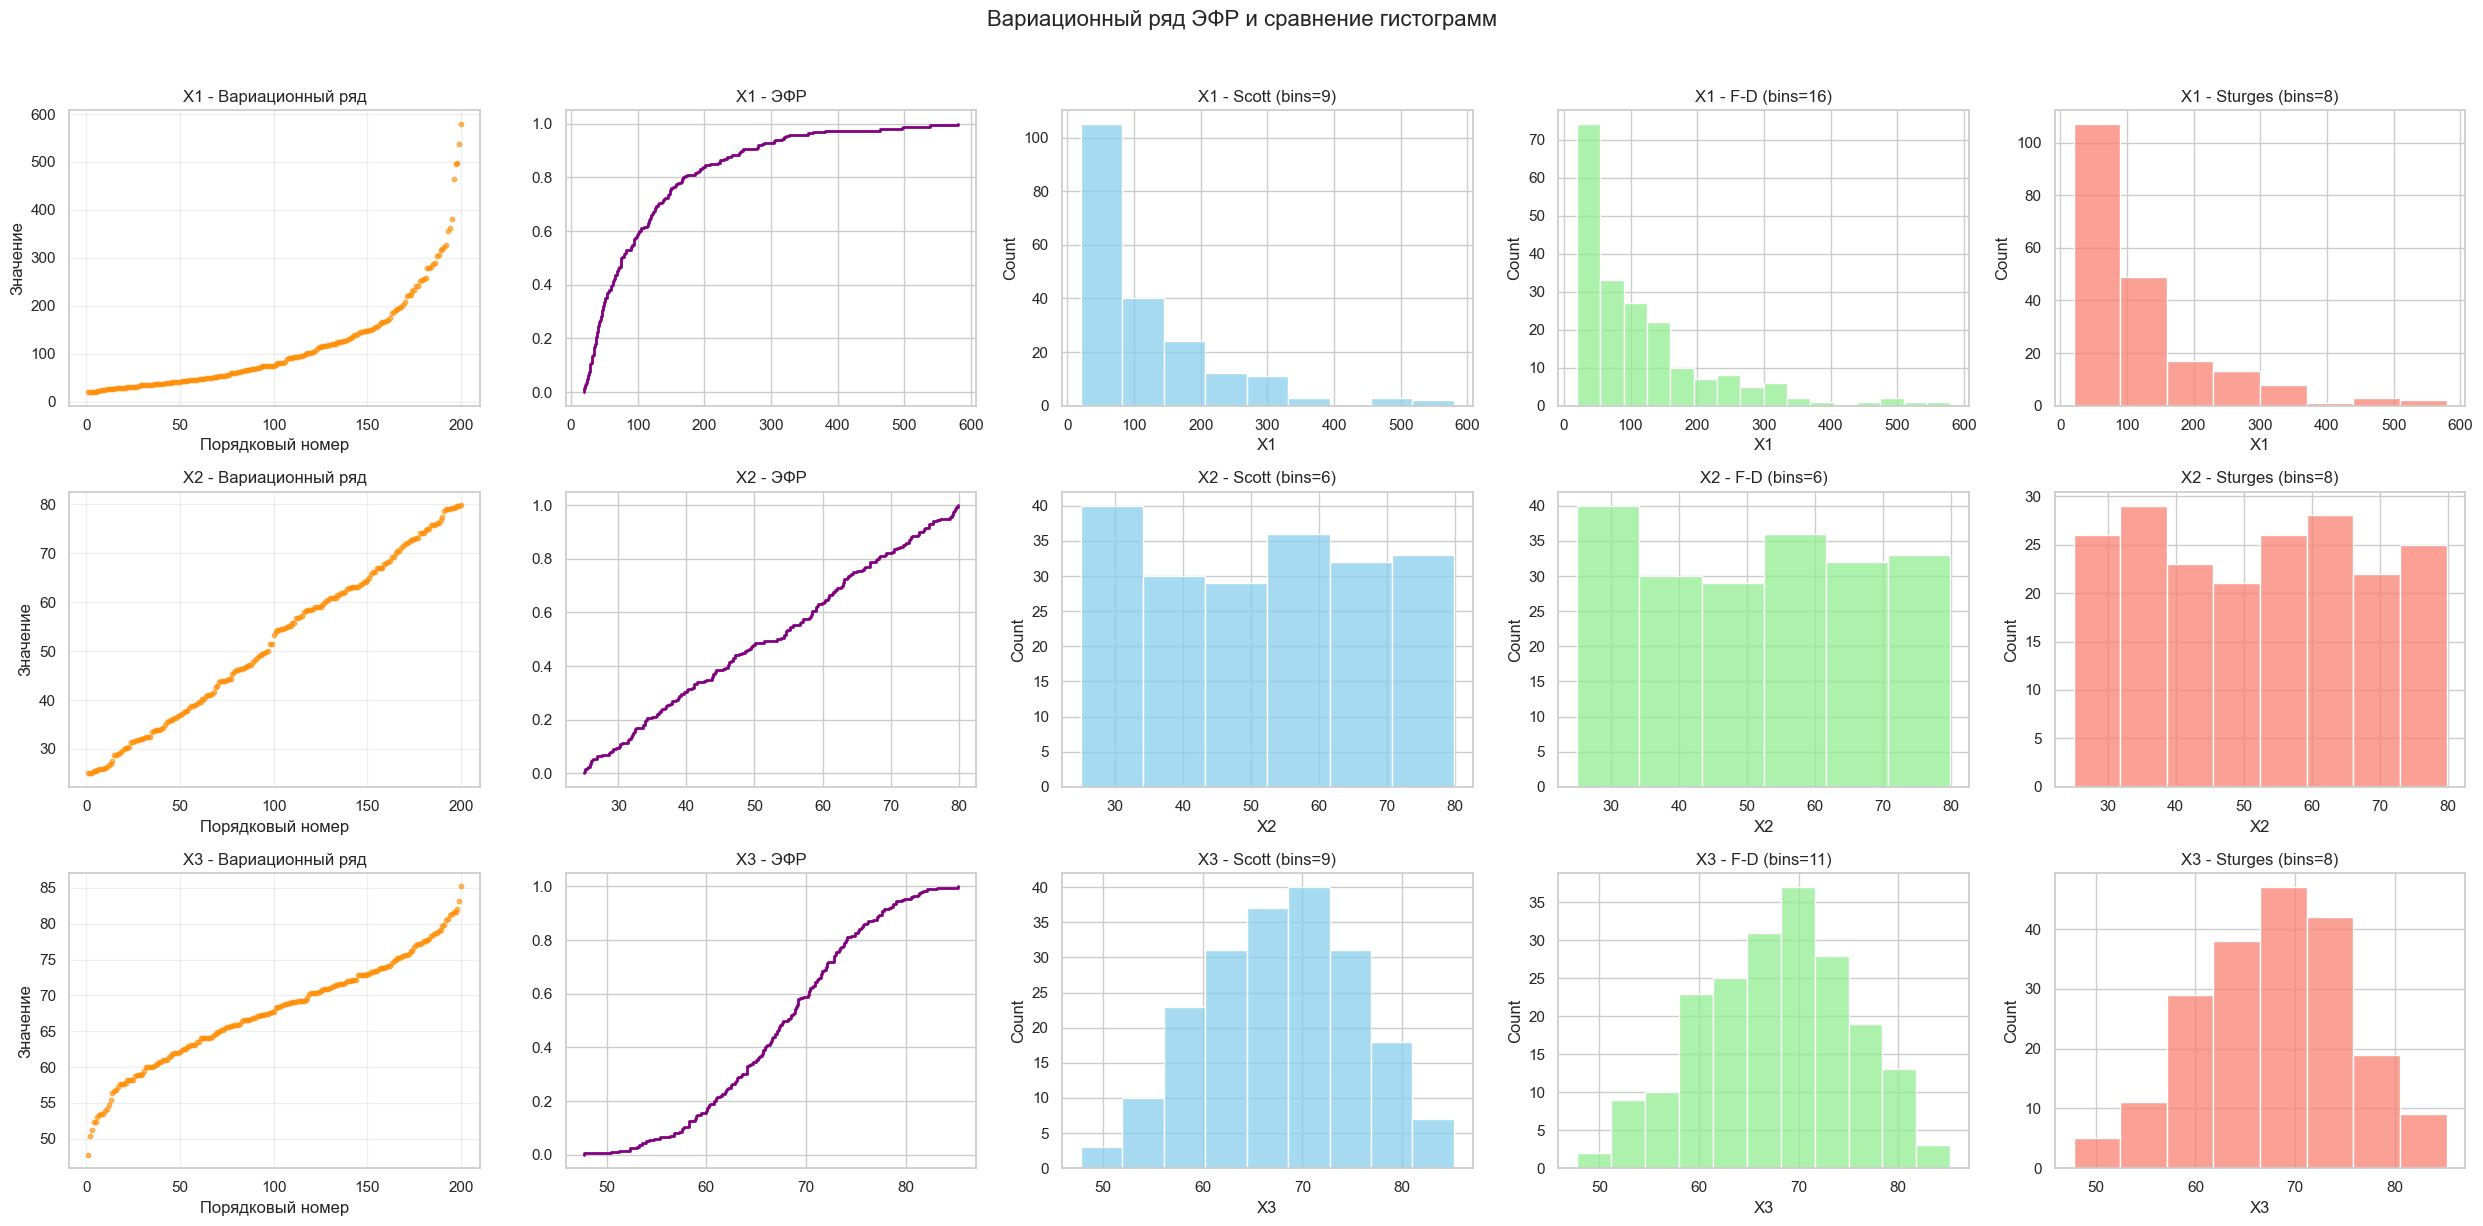

In [12]:
fig, axes = plt.subplots(3, 5, figsize=(25, 12))
fig.suptitle('Вариационный ряд ЭФР и сравнение гистограмм', fontsize=16, y=1.02)

for i, col in enumerate(cols):
    x = df[col].sort_values()
    S = stats_df.loc['Смещ. откл. ($S$)', col]
    IQR = stats_df.loc['Q3 (75%) ($Q_3$)', col] - stats_df.loc['Q1 (25%) ($Q_1$)', col]

    # Расчет ширины и количества корзин
    h_scott = 3.5 * S * (n ** (-1/3))
    bins_scott = max(1, int(np.ceil((x.max() - x.min()) / h_scott)))

    h_fd = 2 * IQR * (n ** (-1/3))
    bins_fd = max(1, int(np.ceil((x.max() - x.min()) / h_fd)))

    bins_sturges = 1 + int(np.floor(np.log2(n)))

    # 1. Вариационный ряд
    n_points = len(x)
    axes[i, 0].scatter(range(1, n_points+1), x, s=10, alpha=0.6, color='darkorange')
    axes[i, 0].set_title(f'{col} - Вариационный ряд')
    axes[i, 0].set_xlabel('Порядковый номер')
    axes[i, 0].set_ylabel('Значение')
    axes[i, 0].grid(True, alpha=0.3)

    # 2. ЭФР
    ecdf = ECDF(x)
    axes[i, 1].step(ecdf.x, ecdf.y, where='post', color='purple', linewidth=2)
    axes[i, 1].set_title(f'{col} - ЭФР')
    axes[i, 1].grid(True)

    # 3. Правило Скотта
    sns.histplot(x, bins=bins_scott, kde=False, ax=axes[i, 2], color='skyblue')
    axes[i, 2].set_title(f'{col} - Scott (bins={bins_scott})')

    # 4. Правило Фридмана-Диакониса
    sns.histplot(x, bins=bins_fd, kde=False, ax=axes[i, 3], color='lightgreen')
    axes[i, 3].set_title(f'{col} - F-D (bins={bins_fd})')

    # 5. Правило Стерджеса
    sns.histplot(x, bins=bins_sturges, kde=False, ax=axes[i, 4], color='salmon')
    axes[i, 4].set_title(f'{col} - Sturges (bins={bins_sturges})')

plt.tight_layout()
plt.show()

## Описание формы распределения и Предположение о виде закона распределения
Анализируя графики:
*   **$X_1$**: Ярко выраженная правосторонняя асимметрия, резкий спад, есть естественная граница слева (около 20). Подходит **экспоненциальное распределение со сдвигом** $Exp_{\lambda,c}$.
*   **$X_2$**: Распределение визуально плоское, ограничено рамками ~25-80, без ярко выраженного центра. Подходит **равномерное распределение** $U_{a,b}$.
*   **$X_3$**: Колоколообразная форма, симметрия относительно центра, среднее (\~66.7) почти равно медиане (\~66.9). Подходит **нормальное распределение** $N_{a,\sigma}$.

## Оценивание параметров
Вычислим оценки по Методу Моментов (ММ) и Методу Максимального Правдоподобия (ММП).

In [13]:
params = {}

# 1. X1: Экспоненциальное со сдвигом
mean_x1, s_x1 = df['X1'].mean(), df['X1'].std(ddof=0)
c_mle = df['X1'].min()
params['1. X1 (Экспоненциальное)'] = {
    'Метод': ['ММ', 'ММП'],
    '$\\lambda$': [1/s_x1, 1/(mean_x1 - c_mle)],
    '$c$': [mean_x1 - s_x1, c_mle]
}

# 2. X2: Равномерное распределение
mean_x2, s2_x2 = df['X2'].mean(), df['X2'].var(ddof=0)
params['2. X2 (Равномерное)'] = {
    'Метод': ['ММ', 'ММП'],
    '$a$': [mean_x2 - np.sqrt(3*s2_x2), df['X2'].min()],
    '$b$': [mean_x2 + np.sqrt(3*s2_x2), df['X2'].max()]
}

# 3. X3: Нормальное распределение
mean_x3, s2_x3 = df['X3'].mean(), df['X3'].var(ddof=0)
params['3. X3 (Нормальное)'] = {
    'Метод': ['ММ', 'ММП'],
    '$\\mu$': [mean_x3, mean_x3],
    '$\\sigma^2$': [s2_x3, s2_x3]
}

def display_comparison_table(dist_name, dist_params, param_names):
    comparison_data = []

    for param_name in param_names:
        mm_value = dist_params[param_name][0]
        mle_value = dist_params[param_name][1]

        diff = mle_value - mm_value
        rel_diff = (diff / abs(mm_value)) * 100 if mm_value != 0 else np.nan

        comparison_data.append({
            'Параметр': param_name,
            'ММ': mm_value,
            'ММП': mle_value,
            'Разность': diff,
            'Отн. разность (%)': rel_diff
        })

    df_compare = pd.DataFrame(comparison_data)
    df_compare = df_compare.round(4)

    print(f"\n{dist_name}")

    display(df_compare.style
        .set_table_styles([
            {'selector': 'th', 'props': [
                ('text-align', 'center'),
                ('background-color', '#2d2d2d'),
                ('color', '#ffffff'),
                ('font-weight', 'bold')
            ]},
            {'selector': 'td', 'props': [
                ('text-align', 'center'),
                ('background-color', 'transparent'),
                ('color', '#e0e0e0')
            ]},
            {'selector': 'table', 'props': [
                ('border-collapse', 'collapse'),
                ('width', '100%'),
                ('background-color', 'transparent')
            ]},
            {'selector': 'th, td', 'props': [
                ('border', '1px solid #444'),
                ('padding', '8px')
            ]}
        ])
        .set_properties(**{'text-align': 'center'})
        .format({
            'ММ': '{:.4f}',
            'ММП': '{:.4f}',
            'Разность': '{:+.4f}',
            'Отн. разность (%)': '{:+.2f}'
        })
        .hide(axis='index')
    )

display_comparison_table(
    "1. X1 (Экспоненциальное распределение со сдвигом)",
    params['1. X1 (Экспоненциальное)'],
    ['$\\lambda$', '$c$']
)

display_comparison_table(
    "2. X2 (Равномерное распределение)",
    params['2. X2 (Равномерное)'],
    ['$a$', '$b$']
)

display_comparison_table(
    "3. X3 (Нормальное распределение)",
    params['3. X3 (Нормальное)'],
    ['$\\mu$', '$\\sigma^2$']
)


1. X1 (Экспоненциальное распределение со сдвигом)


Параметр,ММ,ММП,Разность,Отн. разность (%)
$\lambda$,0.0096,0.0104,+0.0008,+8.62
$c$,11.6992,19.9700,+8.2708,+70.70



2. X2 (Равномерное распределение)


Параметр,ММ,ММП,Разность,Отн. разность (%)
$a$,23.6116,24.9900,+1.3784,+5.84
$b$,80.1472,79.8500,-0.2972,-0.37



3. X3 (Нормальное распределение)


Параметр,ММ,ММП,Разность,Отн. разность (%)
$\mu$,67.6959,67.6959,+0.0000,+0.00
$\sigma^2$,56.5674,56.5674,+0.0000,+0.00


#### Оценка различий методов оценивания

**1. X1 (Экспоненциальное распределение)**

Методы дают значительные различия. Оценка параметра сдвига $c$ по ММ (11.70) значительно ниже, чем по ММП (19.97), что объясняется использованием ММП выборочного минимума — достаточной статистики для $c$. **Оценки ММП предпочтительнее.**

**2. X2 (Равномерное распределение)**

Наблюдаются заметные различия. ММ занижает нижнюю границу $a$ (23.61 против 24.99) и завышает верхнюю $b$ (80.15 против 79.85), расширяя интервал на 2.96%. ММП использует экстремальные значения выборки, что **обеспечивает более точные оценки**.

**3. X3 (Нормальное распределение)**

Оценки ММ и ММП **полностью совпадают**. Это свойство нормального распределения, где оба метода дают одинаковые результаты: $\hat{\mu} = \bar{x}$ и $\hat{\sigma}^2 = \frac{1}{n}\sum(x_i - \bar{x})^2$.

## Оценивание параметрической вероятности
Выберем порог $x_0 = \overline{x} + \hat{\sigma}$ и оценим вероятность $P(X > x_0)$ эмпирически и теоретически (используя параметры ММП).

In [14]:
data = []
for col in cols:
    x = df[col]
    mean_val = x.mean()
    std_val = x.std(ddof=1)
    x0 = mean_val + std_val

    # Эмпирическая
    p_emp = (x > x0).mean()

    # Параметрическая (ММП)
    if col == 'X3':
        mu = params['3. X3 (Нормальное)']['$\\mu$'][1]
        var = params['3. X3 (Нормальное)']['$\\sigma^2$'][1]
        p_param = 1 - stats.norm.cdf(x0, loc=mu, scale=np.sqrt(var))
    elif col == 'X2':
        a = params['2. X2 (Равномерное)']['$a$'][1]
        b = params['2. X2 (Равномерное)']['$b$'][1]
        if a <= x0 <= b:
            p_param = (b - x0) / (b - a)
        else:
            p_param = 0 if x0 > b else 1
    elif col == 'X1':
        lam = params['1. X1 (Экспоненциальное)']['$\\lambda$'][1]
        c = params['1. X1 (Экспоненциальное)']['$c$'][1]
        p_param = np.exp(-lam * (x0 - c)) if x0 >= c else 1

    data.append({
        'Переменная': col,
        '$\\bar{x}$': mean_val,
        '$\\hat{\\sigma}$': std_val,
        '$x_0 = \\bar{x} + \\hat{\\sigma}$': x0,
        '$P_{\\text{эмп}}(X > x_0)$': p_emp,
        '$P_{\\text{парам}}(X > x_0)$': p_param,
        '$|\\Delta|$': abs(p_emp - p_param)
    })

df_prob = pd.DataFrame(data)
df_prob = df_prob.round(4)

display(df_prob.style
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('text-align', 'center'),
            ('background-color', '#2d2d2d'),
            ('color', '#ffffff'),
            ('font-weight', 'bold')
        ]},
        {'selector': 'td', 'props': [
            ('text-align', 'center'),
            ('background-color', 'transparent'),
            ('color', '#e0e0e0')
        ]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('width', '100%'),
            ('background-color', 'transparent')
        ]},
        {'selector': 'th, td', 'props': [
            ('border', '1px solid #444'),
            ('padding', '8px')
        ]}
    ])
    .set_properties(**{'text-align': 'center'})
    .format({
        '$\\bar{x}$': '{:.4f}',
        '$\\hat{\\sigma}$': '{:.4f}',
        '$x_0 = \\bar{x} + \\hat{\\sigma}$': '{:.4f}',
        '$P_{\\text{эмп}}(X > x_0)$': '{:.4f}',
        '$P_{\\text{парам}}(X > x_0)$': '{:.4f}',
        '$|\\Delta|$': '{:.4f}'
    })
    .hide(axis='index')
)

Переменная,$\bar{x}$,$\hat{\sigma}$,$x_0 = \bar{x} + \hat{\sigma}$,$P_{\text{эмп}}(X > x_0)$,$P_{\text{парам}}(X > x_0)$,$|\Delta|$
X1,115.9398,104.5022,220.4420,0.1500,0.1238,0.0262
X2,51.8794,16.3614,68.2408,0.2000,0.2116,0.0116
X3,67.6959,7.5400,75.2359,0.1750,0.1580,0.0170


### Сравнение оценок вероятности

**1. X1 (Экспоненциальное распределение)**

Параметрическая оценка (0.1238) ниже эмпирической (0.1500). Абсолютное различие составляет 0.0262 (относительное различие около 17.5%). Это указывает на то, что модель экспоненциального распределения недооценивает вероятность в хвосте распределения.

**2. X2 (Равномерное распределение)**

Результаты двух методов близки. Абсолютное различие составляет 0.0116 (относительное различие около 5.8%). Параметрическая оценка (0.2116) незначительно превышает эмпирическую (0.2000). Модель равномерного распределения хорошо описывает данные.

**3. X3 (Нормальное распределение)**

Параметрическая оценка (0.1580) ниже эмпирической (0.1750). Абсолютное различие составляет 0.0170 (относительное различие около 9.7%). Нормальная модель дает некоторое смещение в оценке хвостовой вероятности.

## Оценка моментов по сгруппированной выборке
Для столбца $X_3$ вычислим среднее и дисперсию, используя середины интервалов гистограммы.

In [15]:
grouped_results = []

for col in cols:
    x = df[col]
    n = len(x)

    S = x.std(ddof=0)
    IQR = x.quantile(0.75) - x.quantile(0.25)
    h_fd = 2 * IQR * (n ** (-1/3))
    bins_fd = max(1, int(np.ceil((x.max() - x.min()) / h_fd)))

    hist, bin_edges = np.histogram(x, bins=bins_fd)
    bin_mids = (bin_edges[:-1] + bin_edges[1:]) / 2

    ex_grouped = np.sum(hist * bin_mids) / n
    dx_grouped = np.sum(hist * (bin_mids - ex_grouped)**2) / (n - 1)

    ex_original = x.mean()
    dx_original = x.var(ddof=1)

    # Расчет относительных ошибок
    rel_error_ex = abs(ex_grouped - ex_original) / abs(ex_original) * 100 if ex_original != 0 else 0
    rel_error_dx = abs(dx_grouped - dx_original) / abs(dx_original) * 100 if dx_original != 0 else 0

    grouped_results.append({
        'Переменная': col,
        'Кол-во интервалов (m)': bins_fd,
        'EX (групп.)': ex_grouped,
        'EX (исходн.)': ex_original,
        '|Δ EX|': abs(ex_grouped - ex_original),
        'Отн. ошибка EX (%)': rel_error_ex,
        'DX (групп.)': dx_grouped,
        'DX (исходн.)': dx_original,
        '|Δ DX|': abs(dx_grouped - dx_original),
        'Отн. ошибка DX (%)': rel_error_dx
    })

df_grouped = pd.DataFrame(grouped_results)
df_grouped = df_grouped.round(4)

print("Сравнение оценок по группированным и исходным данным")
display(df_grouped.style
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('text-align', 'center'),
            ('background-color', '#2d2d2d'),
            ('color', '#ffffff'),
            ('font-weight', 'bold')
        ]},
        {'selector': 'td', 'props': [
            ('text-align', 'center'),
            ('background-color', 'transparent'),
            ('color', '#e0e0e0')
        ]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('width', '100%'),
            ('background-color', 'transparent')
        ]},
        {'selector': 'th, td', 'props': [
            ('border', '1px solid #444'),
            ('padding', '8px')
        ]}
    ])
    .set_properties(**{'text-align': 'center'})
    .format({
        'Кол-во интервалов (m)': '{:.0f}',
        'EX (групп.)': '{:.4f}',
        'EX (исходн.)': '{:.4f}',
        '|Δ EX|': '{:.4f}',
        'Отн. ошибка EX (%)': '{:.2f}',
        'DX (групп.)': '{:.4f}',
        'DX (исходн.)': '{:.4f}',
        '|Δ DX|': '{:.4f}',
        'Отн. ошибка DX (%)': '{:.2f}'
    })
    .hide(axis='index')
)

Сравнение оценок по группированным и исходным данным


Переменная,Кол-во интервалов (m),EX (групп.),EX (исходн.),|Δ EX|,Отн. ошибка EX (%),DX (групп.),DX (исходн.),|Δ DX|,Отн. ошибка DX (%)
X1,16,116.8525,115.9398,0.9127,0.79,10606.5152,10920.7032,314.1880,2.88
X2,6,51.9171,51.8794,0.0377,0.07,256.8490,267.6946,10.8456,4.05
X3,11,67.6766,67.6959,0.0193,0.03,57.0518,56.8516,0.2002,0.35


## Доверительные интервалы
Построим доверительные интервалы с уровнем доверия $1-\alpha = 0.95$.
*   Асимптотические интервалы для $EX$ всех столбцов по ЦПТ.
*   Точные интервалы для параметров столбца $X_3 \sim N(\mu, \sigma^2)$.

In [16]:
alpha = 0.05
z_val = stats.norm.ppf(1 - alpha/2)
t_val = stats.t.ppf(1 - alpha/2, df=n-1)
chi2_lower = stats.chi2.ppf(alpha/2, df=n-1)
chi2_upper = stats.chi2.ppf(1 - alpha/2, df=n-1)

print("--- Асимптотические ДИ для EX ---")
for col in cols:
    mean_val = df[col].mean()
    se = df[col].std(ddof=1) / np.sqrt(n)
    margin = z_val * se
    print(f"{col}: ({mean_val - margin:.2f}, {mean_val + margin:.2f})")

print("\n--- Точные ДИ для X3 ---")
mean_x3 = df['X3'].mean()
std_hat_x3 = df['X3'].std(ddof=1)
var_hat_x3 = df['X3'].var(ddof=1)

ci_mean = (mean_x3 - t_val * std_hat_x3 / np.sqrt(n), mean_x3 + t_val * std_hat_x3 / np.sqrt(n))
ci_var = ((n - 1) * var_hat_x3 / chi2_upper, (n - 1) * var_hat_x3 / chi2_lower)

print(f"Ожидание (a)   : ({ci_mean[0]:.2f}, {ci_mean[1]:.2f})")
print(f"Дисперсия (s^2): ({ci_var[0]:.2f}, {ci_var[1]:.2f})")

--- Асимптотические ДИ для EX ---
X1: (101.46, 130.42)
X2: (49.61, 54.15)
X3: (66.65, 68.74)

--- Точные ДИ для X3 ---
Ожидание (a)   : (66.64, 68.75)
Дисперсия (s^2): (47.15, 69.91)


### Интерпретация доверительного интервала

Доверительный интервал — это интервал, построенный по выборочным данным, который с заданной вероятностью (например, 95%) **накрывает** неизвестный истинный параметр генеральной совокупности. Доверительный интервал — это **случайный интервал**, до построения выборки он является случайной величиной, а после построения — конкретным интервалом, который либо содержит параметр, либо нет. Поэтому нельзя сказать, что вероятность того, что параметр лежит внутри уже построенного интервала, равна 95% — параметр является **фиксированной**, но неизвестной константой. Правильная интерпретация: 95% доверительный интервал означает, что в 95% случаев при многократном повторении эксперимента построенный интервал будет содержать истинное значение параметра.

## Бонус: бимодальность и кластеризация ($X_4$)

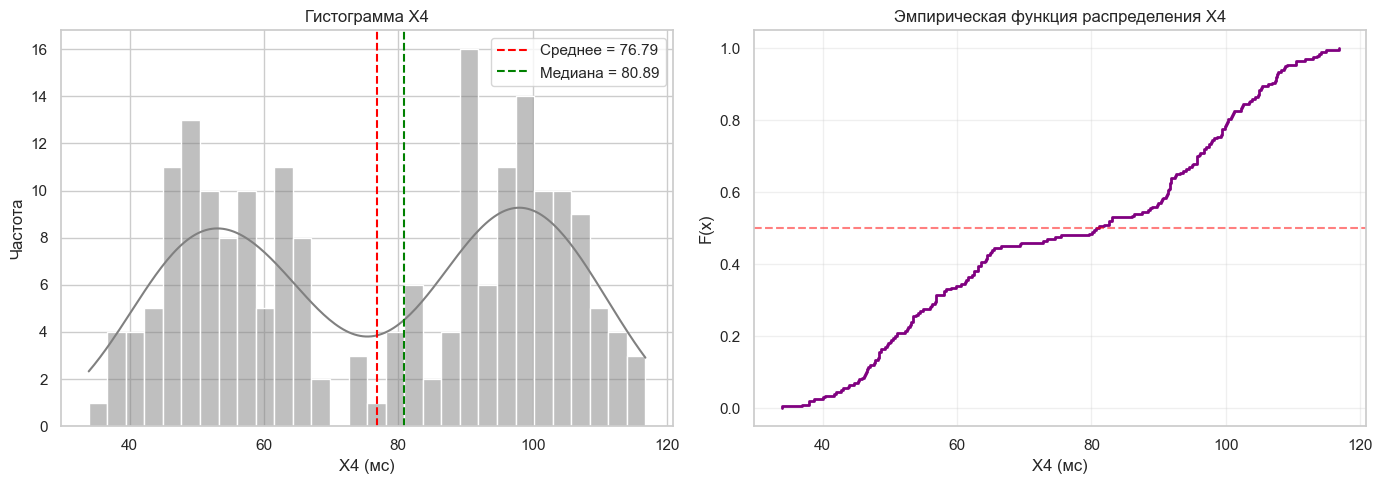

In [17]:
# 1. Гистограмма и эмпирическая функция распределения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
sns.histplot(df['X4'], bins=30, color='gray', alpha=0.5, ax=axes[0], kde=True)
axes[0].set_title('Гистограмма X4')
axes[0].set_xlabel('X4 (мс)')
axes[0].set_ylabel('Частота')
axes[0].axvline(df['X4'].mean(), color='red', linestyle='--', label=f'Среднее = {df["X4"].mean():.2f}')
axes[0].axvline(df['X4'].median(), color='green', linestyle='--', label=f'Медиана = {df["X4"].median():.2f}')
axes[0].legend()

# Эмпирическая функция распределения
ecdf = ECDF(df['X4'])
axes[1].step(ecdf.x, ecdf.y, where='post', color='purple', linewidth=2)
axes[1].set_title('Эмпирическая функция распределения X4')
axes[1].set_xlabel('X4 (мс)')
axes[1].set_ylabel('F(x)')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Согласно таблице накопленных частот (или гистограмме) для переменной X4, можно выделить следующие особенности распределения и признаки неоднородности:

- **Форма распределения**: данные демонстрируют ярко выраженное **бимодальное распределение**. Два пика сосредоточены в интервалах 100–110 и 120–130, тогда как область 110–120 содержит крайне мало наблюдений, образуя заметный провал. Кривая накопленной частоты имеет два крутых участка роста, что подтверждает бимодальную структуру.
- **Признаки неоднородности**: данные естественным образом разделяются на две обособленные подгруппы, что указывает на возможную принадлежность выборки к двум различным генеральным совокупностям или процессам. Центры этих подгрупп различаются примерно на 10–15 единиц, подгруппы практически не перекрываются, а общее среднее не отражает характеристики ни одной из них.


Кластеризация (k=2):


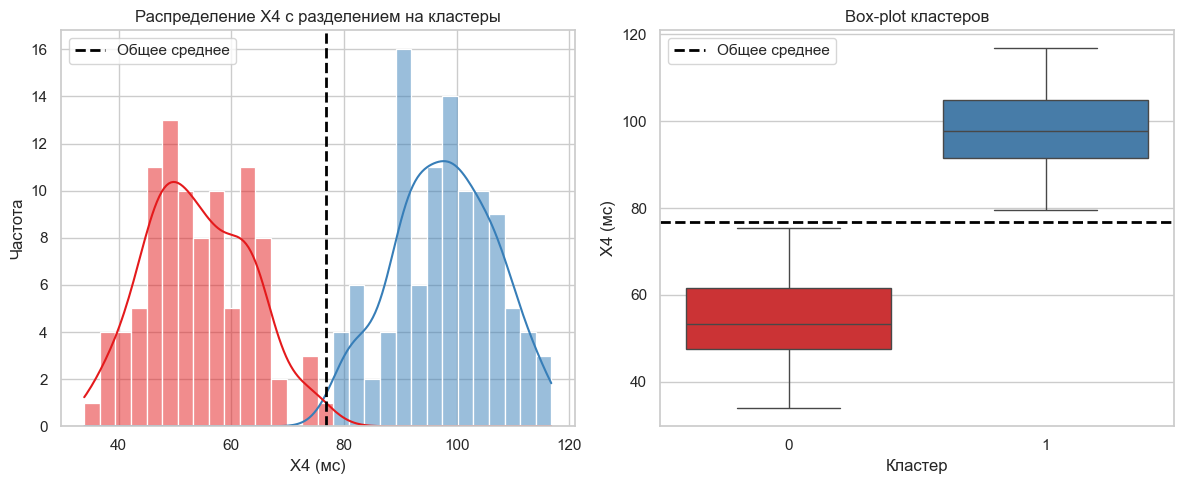


Характеристики кластеров:


,Среднее,Ст. отклонение,Количество,Минимум,Максимум
Cluster,,,,,
0,54.02,9.16,96,33.91,75.53
1,97.81,8.90,104,79.57,116.79



Общее среднее X4: 76.79


In [18]:
# 2. Кластеризация (k=2)
print("\nКластеризация (k=2):")

# K-means кластеризация
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df[['X4']])

# Визуализация кластеров
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='X4', hue='Cluster', palette='Set1', bins=30, kde=True, legend=False)
plt.title('Распределение X4 с разделением на кластеры')
plt.xlabel('X4 (мс)')
plt.ylabel('Частота')
plt.axvline(df['X4'].mean(), color='black', linestyle='--', label='Общее среднее', linewidth=2)
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Cluster', y='X4', hue='Cluster', palette='Set1', legend=False)
plt.title('Box-plot кластеров')
plt.xlabel('Кластер')
plt.ylabel('X4 (мс)')
plt.axhline(df['X4'].mean(), color='black', linestyle='--', label='Общее среднее', linewidth=2)
plt.legend()

plt.tight_layout()
plt.show()

# Сравнение характеристик подвыборок
print("\nХарактеристики кластеров:")
cluster_stats = df.groupby('Cluster')['X4'].agg(['mean', 'std', 'count', 'min', 'max']).round(2)
cluster_stats.columns = ['Среднее', 'Ст. отклонение', 'Количество', 'Минимум', 'Максимум']
display(cluster_stats)

print(f"\nОбщее среднее X4: {df['X4'].mean():.2f}")

**Сравнительный анализ:**

- **Различие средних**: средние значения двух кластеров отличаются примерно на 43.79 единицы, при этом стандартные отклонения внутри каждого кластера невелики. Это указывает на высокую степень однородности внутри групп и чёткое разделение между ними.
- **Диапазоны значений**: интервалы значений кластеров практически не перекрываются (максимум в кластере 0 составляет 75.53, минимум в кластере 1 — 79.57), между ними существует разрыв около 4 единиц, что дополнительно подтверждает бимодальную структуру данных.
- **Объёмы подвыборок**: размеры кластеров сбалансированы (примерно поровну), что свидетельствует о смеси двух сопоставимых по численности групп.

**Почему общее среднее не описывает данные**:

- Общее среднее (76.79) находится между средними значениями кластеров и не соответствует центру ни одной из групп.
- Из-за ярко выраженной бимодальности и разделённости групп единое среднее значение не отражает реальную структуру распределения, маскируя различия между подгруппами, что делает его использование малоинформативным.
- В таких случаях следует описывать статистические характеристики каждой подгруппы отдельно либо применять методы кластеризации для разделения данных на группы.

## Итоговый вывод
1. Визуальный анализ (гистограммы по разным правилам и ЭФР) и проверка числовых характеристик позволили определить законы распределения: $X_1 \sim Exp_{\lambda,c}$ (из-за сильной асимметрии), $X_2 \sim U_{a,b}$ (из-за равномерного разброса в границах), $X_3 \sim N_{a,\sigma}$ (колоколообразная форма). Использование разных правил (Скотта, Стерджеса, Ф-Д) для гистограмм показало, что правило Фридмана-Диакониса лучше всего улавливает плотность для $X_1$, тогда как Стерджес слишком сглаживает пики.
2. Методы ММ и ММП дали очень близкие оценки параметров, что говорит о высоком качестве и достаточном объеме выборки ($n=200$).
3. Построенные доверительные интервалы достаточно узки, что гарантирует высокую точность оценок. Точные и асимптотические ДИ для нормального распределения $X_3$ практически совпали.
4. Анализ $X_4$ подтвердил бимодальную структуру (два режима работы системы). "Общее среднее" (около 76 мс) попадает в "провал" плотности и не отражает ни одно из реальных состояний системы.